In [1]:
!pip install rdkit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.1/38.1 MB 30.4 MB/s eta 0:00:00


In [2]:
from rdkit import Chem
from rdkit.Chem import AllChem, Draw, Descriptors
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
import matplotlib.pyplot as plt

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
cd drive/MyDrive/Colab Notebooks/2609_FluorescentClassification/data

/content/drive/MyDrive/Colab Notebooks/2609_FluorescentClassification/data


In [5]:
# pandas print option
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', 200)

In [6]:
# Canonical SMILES Function
def to_canonical(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol:
        return Chem.MolToSmiles(mol, canonical=True)
    else:
        return None

In [7]:
# Non-Fluorescent
df_N = pd.read_csv('nonfluorescent.csv', encoding='utf-8-sig')

df_N['SMILES'] = df_N['SMILES'].apply(to_canonical)
df_N = df_N.drop_duplicates(subset='SMILES', keep='first')
df_N = df_N.reset_index(drop=True)

display(df_N)

,SMILES
0,Nc1c(/N=N/c2ccc([N+](=O)[O-])cc2)c(S(=O)(=O)[O][Na])cc2c1C(=O)/C(=N\Nc1ccccc1)C(S(=O)(=O)[O][Na])=C2
1,Nc1c(/N=N/c2ccc(S(=O)(=O)[O][Na])cc2)cc(S(=O)(=O)[O][Na])c2c1C(=O)/C(=N\Nc1ccc([N+](=O)[O-])cc1)C=C2
2,Nc1c(/N=N/c2ccc(S(=O)(=O)[O][Na])cc2)cc(S(=O)(=O)[O][Na])c2c1C(=O)/C(=N\Nc1cccc3ccccc13)C=C2
3,O=[N+]([O-])c1ccc2c(/N=N/c3c(O)ccc4ccccc34)c(O)cc(S(=O)(=O)[O][Na])c2c1
4,Nc1ccc(S(=O)(=O)[O][Na])c2c1C(=O)/C(=N\Nc1ccc(/N=N/c3ccc(S(=O)(=O)[O][Na])cc3)c3ccccc13)C(S(=O)(=O)[O][Na])=C2
...,...
2549,O=C(Nc1ccc(NC(=O)c2ccccc2)c2c1C(=O)c1ccccc1C2=O)c1ccccc1
2550,Nc1nc(-c2ccc(NC(=O)c3ccccc3)c3c2C(=O)c2ccccc2C3=O)nc(-c2ccc(NC(=O)c3ccccc3)c3c2C(=O)c2ccccc2C3=O)n1
2551,O=C1/C(=c2/c(=O)c3cccc4cccc2c43)Sc2ccccc21
2552,O=C1/C(=C2\Sc3cc(Cl)ccc3C2=O)Sc2cc(Cl)ccc21


In [8]:
# Fluorescent
df_F = pd.read_csv('fluorescent.csv', encoding='utf-8-sig')

df_F['SMILES'] = df_F['SMILES'].apply(to_canonical)
df_F = df_F.drop_duplicates(subset='SMILES', keep='first')
df_F = df_F.reset_index(drop=True)

display(df_F)

,SMILES
0,COC(=O)c1ccn2cc(-c3ccc(OC)cc3)nc2c1
1,COC(=O)c1ccn2c(N)c(-c3ccc(OC)cc3)nc2c1
2,COC(=O)c1ccn2c(NC3CCCCC3)c(-c3ccc(OC)cc3)nc2c1
3,COC(=O)c1cccc2nc(-c3ccc(OC)cc3)c(NC3CCCCC3)n12
4,COc1ccc(-c2nc3ncccn3c2NC2CCCCC2)cc1
...,...
2907,CN(C)c1ccc(-c2ccc3c(=O)c(O)coc3c2)cc1
2908,COc1coc2cc(-c3ccc(N(C)C)cc3)ccc2c1=O
2909,COC(=O)CN1C(=O)c2cc3ccc(N(C)C)cc3cc2C1=O
2910,CCN(CC)c1ccc2c(c1)C(C)(C)c1cc(C=O)ccc1-2


In [9]:
# df_Ndye
Ndye_smiles_list = df_N['SMILES'].tolist()
Ndye_indices = df_N.index.tolist()  # ← Save index list

# df_Fdye
Fdye_smiles_list = df_F['SMILES'].tolist()
Fdye_indices = df_F.index.tolist()  # ← Save index list

In [10]:
from rdkit import Chem
from rdkit.Chem import Descriptors, rdMolDescriptors

def calc_basic_descriptors(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        raise ValueError("Invalid SMILES")

    # 1) Molecular weight
    mol_wt = Descriptors.MolWt(mol)

    # 2) Num Rings count
    num_rings = rdMolDescriptors.CalcNumRings(mol)

    # 3) Num Aromatic Rings count
    num_aromatic_rings = rdMolDescriptors.CalcNumAromaticRings(mol)

    # 4) Conjugated bond fraction
    total_bonds = mol.GetNumBonds()
    conjugated_bonds = sum(1 for bond in mol.GetBonds() if bond.GetIsConjugated())
    frac_conj = conjugated_bonds / total_bonds if total_bonds > 0 else 0.0
    # print('total bonds', total_bonds)
    # print('conjugated bonds', conjugated_bonds)

    # 5) Fraction CSP3
    frac_csp3 = rdMolDescriptors.CalcFractionCSP3(mol)

    # 6) BertzCT
    bertz_ct = Descriptors.BertzCT(mol)

    return mol_wt, num_rings, num_aromatic_rings, frac_conj, frac_csp3, bertz_ct


In [11]:
# Example on molecule
smiles = "Cc1cccc(C2=C(c3cccc(C)c3)C3=Cc4ccccc4NB3OB3Nc4ccccc4C=C32)c1"
mw, rings, aromatic_rings, frac_conj, frac_csp3, bertz_ct = calc_basic_descriptors(smiles)

print("=====================================")
print("SMILES:", smiles)
print("Molecular weight:", mw)
print("Ring count:", rings)
print("Aromatic ring count:", aromatic_rings)
print("Conjugated bond fraction:", frac_conj)
print("Fraction CSP3:", frac_csp3)
print("BertzCT:", bertz_ct)

SMILES: Cc1cccc(C2=C(c3cccc(C)c3)C3=Cc4ccccc4NB3OB3Nc4ccccc4C=C32)c1
Molecular weight: 476.1970000000002
Ring count: 7
Aromatic ring count: 4
Conjugated bond fraction: 0.813953488372093
Fraction CSP3: 0.0625
BertzCT: 1531.1286302400417


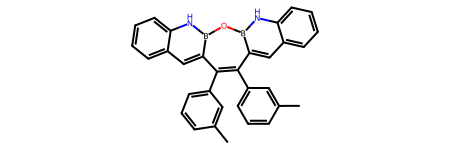

In [12]:
display(Chem.MolFromSmiles(smiles))

In [13]:
# Descriptor df Function
def build_descriptor_df(df, smiles_col="SMILES"):
    smiles_list = df[smiles_col].tolist()
    index_list = df.index.tolist()

    records = []
    fails = []

    for i, smiles in enumerate(smiles_list):
        try:
            mw, rings, aromatic_rings, frac_conj, frac_csp3, bertzct = calc_basic_descriptors(smiles)

            records.append({
                "index":i,
                "SMILES":smiles,
                "Molecular weight":mw,
                "Number of Rings":rings,
                "Number of Aromatic Rings":aromatic_rings,
                "Conjugated bond fraction":frac_conj,
                "Fraction CSP3":frac_csp3,
                "BertzCT":bertzct
            })

        except Exception as e:
            fails.append({
                "index":i,
                "SMILES":smiles,
                "Error":str(e)
            })

    descriptor_df = pd.DataFrame(records).set_index("index") if len(records) > 0 else pd.DataFrame()
    fails_df = pd.DataFrame(fails).set_index("index") if len(fails) > 0 else pd.DataFrame()

    return descriptor_df, fails_df

In [14]:
# Create Non-Fluorescent descriptor dataset
descriptor_N, fails_N = build_descriptor_df(df_N, smiles_col="SMILES")

# Check Result
print("===== Descriptor dataset (Ndye) =====")
print(f"Total input molecules : {len(df_N)}")
print(f"Successfully processed: {len(descriptor_N)}")
print(f"Failed molecules      : {len(fails_N)}")
display(descriptor_N)

# Check fail cases
if len(fails_N) > 0:
    print("\n===== Failed SMILES examples =====")
    display(fails_N)


===== Descriptor dataset (Ndye) =====
Total input molecules : 2554
Successfully processed: 2554
Failed molecules      : 0


,SMILES,Molecular weight,Number of Rings,Number of Aromatic Rings,Conjugated bond fraction,Fraction CSP3,BertzCT
index,,,,,,,
0,Nc1c(/N=N/c2ccc([N+](=O)[O-])cc2)c(S(=O)(=O)[O][Na])cc2c1C(=O)/C(=N\Nc1ccccc1)C(S(=O)(=O)[O][Na])=C2,616.501,4,3,0.772727,0.0,1863.275289
1,Nc1c(/N=N/c2ccc(S(=O)(=O)[O][Na])cc2)cc(S(=O)(=O)[O][Na])c2c1C(=O)/C(=N\Nc1ccc([N+](=O)[O-])cc1)C=C2,616.501,4,3,0.772727,0.0,1860.520402
2,Nc1c(/N=N/c2ccc(S(=O)(=O)[O][Na])cc2)cc(S(=O)(=O)[O][Na])c2c1C(=O)/C(=N\Nc1cccc3ccccc13)C=C2,621.564,5,4,0.782609,0.0,2042.391146
3,O=[N+]([O-])c1ccc2c(/N=N/c3c(O)ccc4ccccc34)c(O)cc(S(=O)(=O)[O][Na])c2c1,461.387,4,4,0.857143,0.0,1537.797231
4,Nc1ccc(S(=O)(=O)[O][Na])c2c1C(=O)/C(=N\Nc1ccc(/N=N/c3ccc(S(=O)(=O)[O][Na])cc3)c3ccccc13)C(S(=O)(=O)[O][Na])=C2,723.610,5,4,0.705882,0.0,2367.354501
...,...,...,...,...,...,...,...
2549,O=C(Nc1ccc(NC(=O)c2ccccc2)c2c1C(=O)c1ccccc1C2=O)c1ccccc1,446.462,5,4,1.000000,0.0,1349.248532
2550,Nc1nc(-c2ccc(NC(=O)c3ccccc3)c3c2C(=O)c2ccccc2C3=O)nc(-c2ccc(NC(=O)c3ccccc3)c3c2C(=O)c2ccccc2C3=O)n1,746.739,9,7,1.000000,0.0,2732.884344
2551,O=C1/C(=c2/c(=O)c3cccc4cccc2c43)Sc2ccccc21,314.365,5,4,0.925926,0.0,1218.479336


In [15]:
# Create Fluorescent descriptor dataset
descriptor_F, fails_F = build_descriptor_df(df_F, smiles_col="SMILES")

# Check Result
print("===== Descriptor dataset (Ndye) =====")
print(f"Total input molecules : {len(df_F)}")
print(f"Successfully processed: {len(descriptor_F)}")
print(f"Failed molecules      : {len(fails_F)}")
display(descriptor_F)

# Check fail cases
if len(fails_F) > 0:
    print("\n===== Failed SMILES examples =====")
    display(fails_F)

===== Descriptor dataset (Ndye) =====
Total input molecules : 2912
Successfully processed: 2912
Failed molecules      : 0


,SMILES,Molecular weight,Number of Rings,Number of Aromatic Rings,Conjugated bond fraction,Fraction CSP3,BertzCT
index,,,,,,,
0,COC(=O)c1ccn2cc(-c3ccc(OC)cc3)nc2c1,282.299,3,3,0.913043,0.125000,790.892233
1,COC(=O)c1ccn2c(N)c(-c3ccc(OC)cc3)nc2c1,297.314,3,3,0.916667,0.125000,837.713358
2,COC(=O)c1ccn2c(NC3CCCCC3)c(-c3ccc(OC)cc3)nc2c1,379.460,4,3,0.709677,0.363636,972.605703
3,COC(=O)c1cccc2nc(-c3ccc(OC)cc3)c(NC3CCCCC3)n12,379.460,4,3,0.709677,0.363636,972.605703
4,COc1ccc(-c2nc3ncccn3c2NC2CCCCC2)cc1,322.412,4,3,0.703704,0.368421,819.004000
...,...,...,...,...,...,...,...
2907,CN(C)c1ccc(-c2ccc3c(=O)c(O)coc3c2)cc1,281.311,3,3,0.913043,0.117647,848.033374
2908,COc1coc2cc(-c3ccc(N(C)C)cc3)ccc2c1=O,295.338,3,3,0.875000,0.166667,863.629818
2909,COC(=O)CN1C(=O)c2cc3ccc(N(C)C)cc3cc2C1=O,312.325,3,2,0.800000,0.235294,841.847408


In [22]:
# Draw Integer Barplot

def barplot_integer_counts(descriptor_F, descriptor_N, col,
                           color_f="Blue", color_n="Red",
                           title=None, xlabel=None, ylabel="Count"):
    # integer counts
    f_counts = descriptor_F[col].dropna().astype(int).value_counts().sort_index()
    n_counts = descriptor_N[col].dropna().astype(int).value_counts().sort_index()

    # Include all integers from the minimum value to the maximum value
    x_vals = range(
        min(f_counts.index.min(), n_counts.index.min()),
        max(f_counts.index.max(), n_counts.index.max()) + 1
    )

    # Common x-axis alignment (value missing is 0)
    x_vals = sorted(set(f_counts.index).union(set(n_counts.index)))
    f_y = np.array([f_counts.get(x, 0) for x in x_vals])
    n_y = np.array([n_counts.get(x, 0) for x in x_vals])

    # grouped bar
    x = np.arange(len(x_vals))
    width = 0.4

    plt.figure(figsize=(4.5, 3))
    plt.bar(x - width/2, f_y, width=width, label="Fluorescent", color=color_f, alpha=0.9)
    plt.bar(x + width/2, n_y, width=width, label="Non-Fluorescent", color=color_n, alpha=0.9)

    plt.xticks(x[::2], list(x_vals)[::2], fontsize=11) # Table of Even Numbers Only
    # plt.xticks(x, x_vals, fontsize=11)
    plt.yticks(fontsize=11)

    plt.xlabel(xlabel if xlabel else col, fontsize=13)
    plt.ylabel(ylabel, fontsize=13)
    # plt.title(title if title else f"{col}")
    plt.legend(fontsize=11.5)
    plt.tight_layout()

    plt.savefig(f"barplot_{col}.png", dpi=600, bbox_inches="tight")
    plt.show()
    plt.close()

    print(f"Average {col} (Fluorescent): {descriptor_F[col].mean():.3f}")
    print(f"Average {col} (Non-Fluorescent): {descriptor_N[col].mean():.3f}")


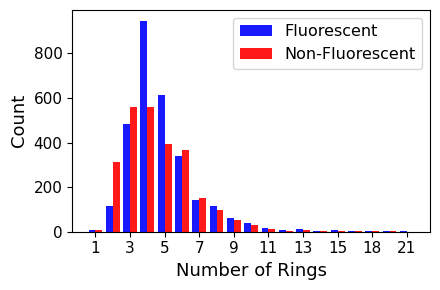

Average Number of Rings (Fluorescent): 4.829
Average Number of Rings (Non-Fluorescent): 4.571


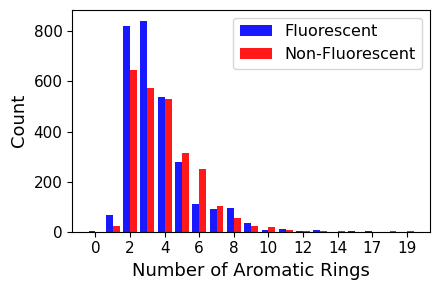

Average Number of Aromatic Rings (Fluorescent): 3.600
Average Number of Aromatic Rings (Non-Fluorescent): 3.920


In [17]:
barplot_integer_counts(descriptor_F, descriptor_N, "Number of Rings")
barplot_integer_counts(descriptor_F, descriptor_N, "Number of Aromatic Rings")


In [23]:
# Draw bin barplot

def barplot_binned_counts(descriptor_F, descriptor_N, col, bins=20,
                          range_=None, color_f="Blue", color_n="Red",
                          title=None, xlabel=None, ylabel="Count"):
    f = descriptor_F[col].dropna().values
    n = descriptor_N[col].dropna().values

    # bin range unification
    if range_ is None:
        min_v = np.nanmin(np.concatenate([f, n]))
        max_v = np.nanmax(np.concatenate([f, n]))
        range_ = (min_v, max_v)

    f_hist, edges = np.histogram(f, bins=bins, range=range_)
    n_hist, _     = np.histogram(n, bins=bins, range=range_)

    centers = (edges[:-1] + edges[1:]) / 2
    bin_width = (edges[1] - edges[0])

    # Slightly reduce the width for the grouped bars
    width = bin_width * 0.45

    plt.figure(figsize=(4.5, 3))
    plt.bar(centers - width/2, f_hist, width=width, label="Fluorescent", color=color_f, alpha=0.9)
    plt.bar(centers + width/2, n_hist, width=width, label="Non-Fluorescent", color=color_n, alpha=0.9)

    plt.xticks(fontsize=11)
    plt.yticks(fontsize=11)

    plt.xlabel(xlabel if xlabel else col, fontsize=13)
    plt.ylabel(ylabel, fontsize=13)
    # plt.title(title if title else f"{col}")
    plt.legend(fontsize=11.5)
    plt.tight_layout()

    plt.savefig(f"barplot_{col}.png", dpi=600, bbox_inches="tight")
    plt.show()
    plt.close()

    print(f"Average {col} (Fluorescent): {descriptor_F[col].mean():.3f}")
    print(f"Average {col} (Non-Fluorescent): {descriptor_N[col].mean():.3f}")


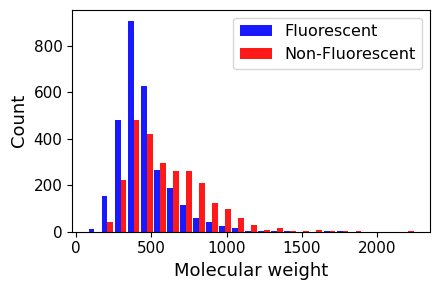

Average Molecular weight (Fluorescent): 452.596
Average Molecular weight (Non-Fluorescent): 597.615


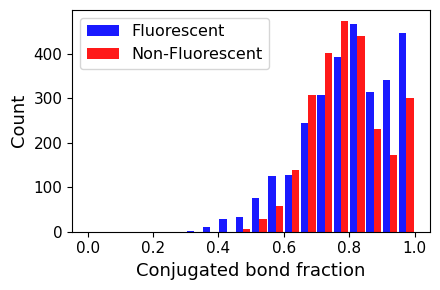

Average Conjugated bond fraction (Fluorescent): 0.798
Average Conjugated bond fraction (Non-Fluorescent): 0.791


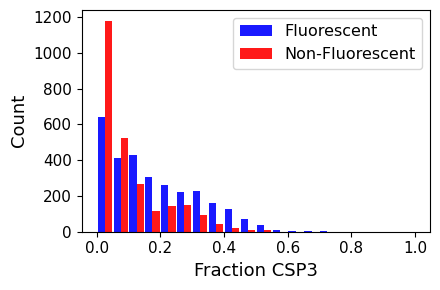

Average Fraction CSP3 (Fluorescent): 0.175
Average Fraction CSP3 (Non-Fluorescent): 0.090


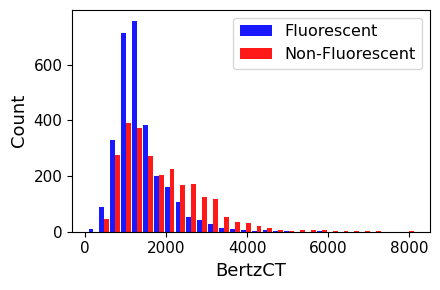

Average BertzCT (Fluorescent): 1391.804
Average BertzCT (Non-Fluorescent): 1854.495


In [19]:
barplot_binned_counts(descriptor_F, descriptor_N, "Molecular weight", bins=25)
barplot_binned_counts(descriptor_F, descriptor_N, "Conjugated bond fraction", bins=20, range_=(0,1))
barplot_binned_counts(descriptor_F, descriptor_N, "Fraction CSP3", bins=20, range_=(0,1))
barplot_binned_counts(descriptor_F, descriptor_N, "BertzCT", bins=30)


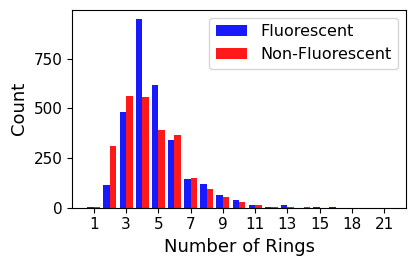

Average Number of Rings (Fluorescent): 4.829
Average Number of Rings (Non-Fluorescent): 4.571


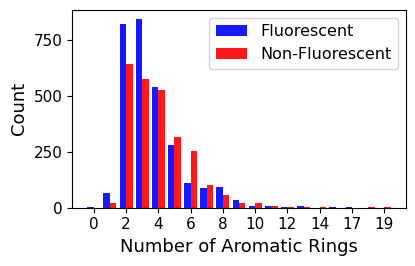

Average Number of Aromatic Rings (Fluorescent): 3.600
Average Number of Aromatic Rings (Non-Fluorescent): 3.920


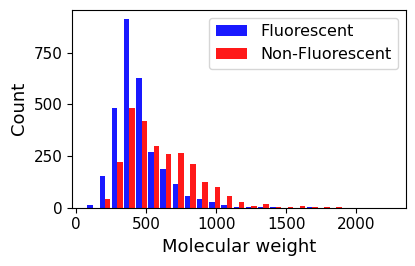

Average Molecular weight (Fluorescent): 452.596
Average Molecular weight (Non-Fluorescent): 597.615


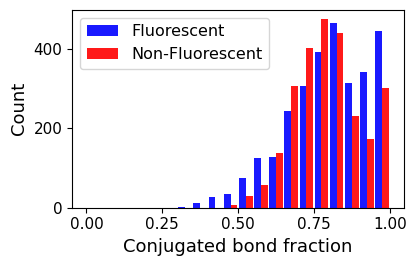

Average Conjugated bond fraction (Fluorescent): 0.798
Average Conjugated bond fraction (Non-Fluorescent): 0.791


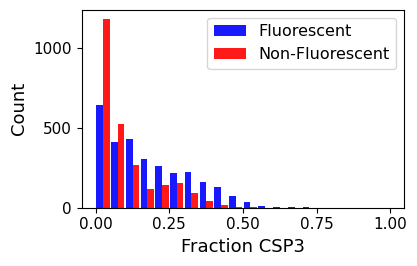

Average Fraction CSP3 (Fluorescent): 0.175
Average Fraction CSP3 (Non-Fluorescent): 0.090


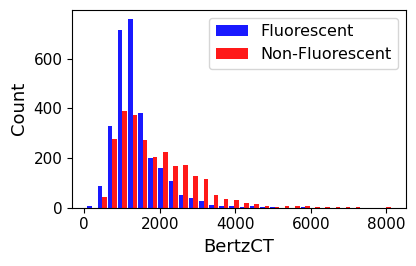

Average BertzCT (Fluorescent): 1391.804
Average BertzCT (Non-Fluorescent): 1854.495


In [24]:
# --------------------------------------------------------
# Draw all descriptor
# --------------------------------------------------------
barplot_integer_counts(descriptor_F, descriptor_N, "Number of Rings")
barplot_integer_counts(descriptor_F, descriptor_N, "Number of Aromatic Rings")
barplot_binned_counts(descriptor_F, descriptor_N, "Molecular weight", bins=25)
barplot_binned_counts(descriptor_F, descriptor_N, "Conjugated bond fraction", bins=20, range_=(0,1))
barplot_binned_counts(descriptor_F, descriptor_N, "Fraction CSP3", bins=20, range_=(0,1))
barplot_binned_counts(descriptor_F, descriptor_N, "BertzCT", bins=30)

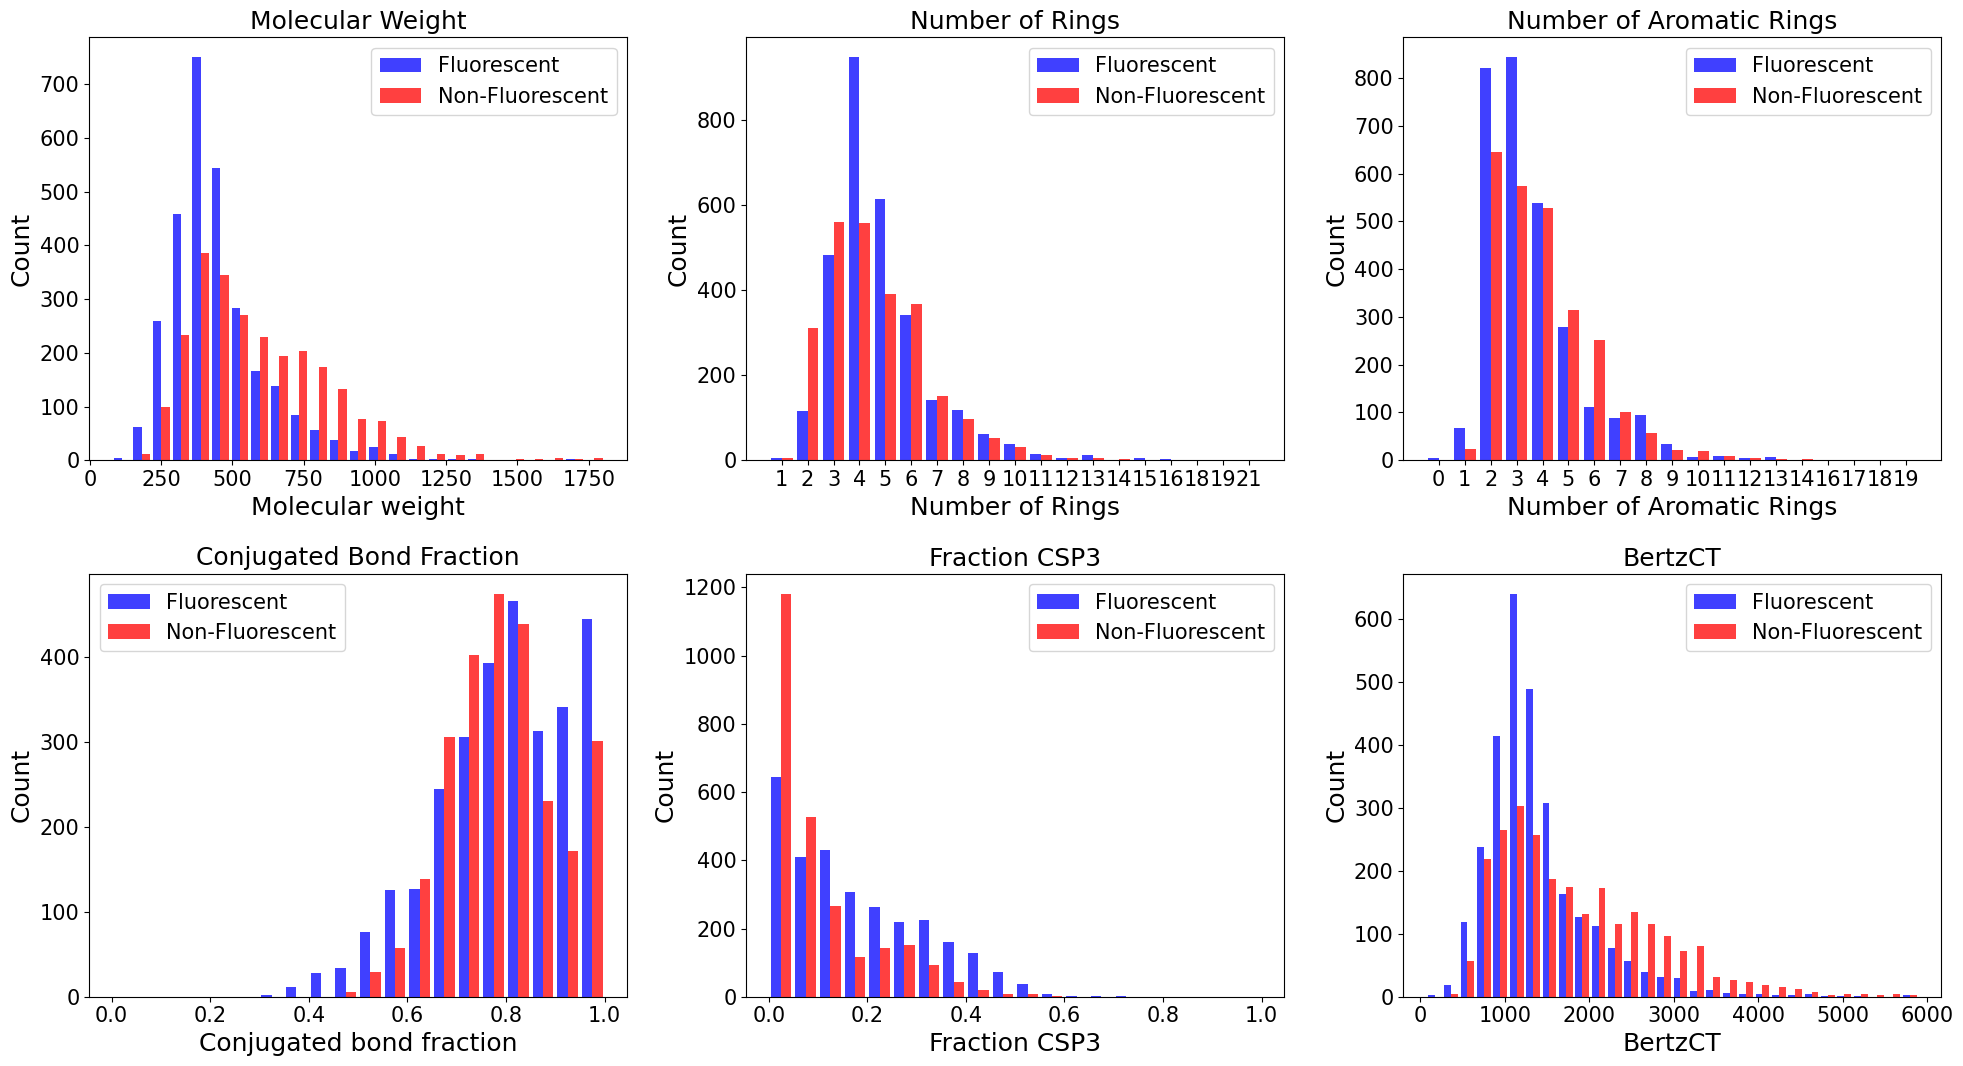

In [20]:
# --------------------------------------------------------
# (Option) Draw all descriptor - Decoration
# --------------------------------------------------------

plt.rcParams.update({
    "font.size": 18,
    "axes.titlesize": 18,
    "axes.labelsize": 18,
    "xtick.labelsize": 15,
    "ytick.labelsize": 15,
    "legend.fontsize": 15
})

# --------------------------------------------------------
# Integer count barplot
# --------------------------------------------------------
def barplot_integer_counts(df_f, df_n, column, ax, title=None):
    f_counts = df_f[column].dropna().astype(int).value_counts().sort_index()
    n_counts = df_n[column].dropna().astype(int).value_counts().sort_index()

    all_idx = sorted(set(f_counts.index).union(set(n_counts.index)))
    f_vals = [f_counts.get(i, 0) for i in all_idx]
    n_vals = [n_counts.get(i, 0) for i in all_idx]

    x = np.arange(len(all_idx))
    width = 0.42

    ax.bar(x - width/2, f_vals, width, label="Fluorescent", color="blue", alpha=0.75)
    ax.bar(x + width/2, n_vals, width, label="Non-Fluorescent", color="red", alpha=0.75)

    ax.set_title(title if title else column)
    ax.set_xlabel(column)
    ax.set_ylabel("Count")
    ax.set_xticks(x)
    ax.set_xticklabels(all_idx)
    ax.legend(frameon=True)


# --------------------------------------------------------
# Binned count barplot
# --------------------------------------------------------
def barplot_binned_counts(df_f, df_n, column, ax, bins=20, range_=None, title=None):
    f_data = df_f[column].dropna()
    n_data = df_n[column].dropna()

    f_counts, bin_edges = np.histogram(f_data, bins=bins, range=range_)
    n_counts, _ = np.histogram(n_data, bins=bin_edges)

    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    bin_width = bin_edges[1] - bin_edges[0]

    width = bin_width * 0.42

    ax.bar(bin_centers - width/2, f_counts, width, label="Fluorescent", color="blue", alpha=0.75)
    ax.bar(bin_centers + width/2, n_counts, width, label="Non-Fluorescent", color="red", alpha=0.75)

    ax.set_title(title if title else column)
    ax.set_xlabel(column)
    ax.set_ylabel("Count")
    ax.legend(frameon=True)


# --------------------------------------------------------
# Figure 3: 2 x 3 subplot
# --------------------------------------------------------
fig, axes = plt.subplots(2, 3, figsize=(20, 11))

barplot_binned_counts(
    descriptor_F, descriptor_N,
    "Molecular weight",
    ax=axes[0, 0],
    bins=25,
    title="Molecular Weight"
)

barplot_integer_counts(
    descriptor_F, descriptor_N,
    "Number of Rings",
    ax=axes[0, 1],
    title="Number of Rings"
)

barplot_integer_counts(
    descriptor_F, descriptor_N,
    "Number of Aromatic Rings",
    ax=axes[0, 2],
    title="Number of Aromatic Rings"
)

barplot_binned_counts(
    descriptor_F, descriptor_N,
    "Conjugated bond fraction",
    ax=axes[1, 0],
    bins=20,
    range_=(0, 1),
    title="Conjugated Bond Fraction"
)

barplot_binned_counts(
    descriptor_F, descriptor_N,
    "Fraction CSP3",
    ax=axes[1, 1],
    bins=20,
    range_=(0, 1),
    title="Fraction CSP3"
)

barplot_binned_counts(
    descriptor_F, descriptor_N,
    "BertzCT",
    ax=axes[1, 2],
    bins=30,
    title="BertzCT"
)

plt.tight_layout()

plt.savefig(
    "all_descriptor_distribution.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()